1) Imports and Configuration 

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import LedoitWolf
import cvxpy as cp

from scipy.optimize import minimize

START_DATE = "2020-01-01"
END_DATE = "2025-01-01"
TRADING_DAYS = 252

MAX_WEIGHT = 0.30       # no stock can exceed 30%
MIN_ESG_SCORE = 22.0    # original ESG-score scale, not normalized
RISK_AVERSION = 0.50
RANDOM_SEED = 42

2) Loading and cleaning ESG Data

In [27]:
esg_df = pd.read_csv("data/ESGrisk.csv")

# Remove whitespace from column names and ticker values
esg_df.columns = esg_df.columns.str.strip()
esg_df["Ticker"] = esg_df["Ticker"].str.strip()

# Ensure ESG scores are numeric
esg_df["ESG Score"] = pd.to_numeric(esg_df["ESG Score"], errors="coerce")

# Keep only valid, unique assets
esg_df = esg_df.dropna(subset=["Ticker", "ESG Score"]).drop_duplicates("Ticker")
esg_df = esg_df.set_index("Ticker")

print(esg_df[["Company Name", "ESG Score"]])

                        Company Name  ESG Score
Ticker                                         
AAPL                      Apple Inc.       18.9
NVDA                   NVIDIA Corp.        12.5
TSLA                     Tesla, Inc.       24.8
JNJ                  Johnson&Johnson       22.4
UNH          UnitedHealth Group Inc.       16.9
PFE                      Pfizer Inc.       18.6
PG      The Procter & Gamble Company       25.8
KO             The Coca-Cola Company       28.3
MCD           McDonald's Corporation       28.5
MA           Mastercard Incorporated       14.3
V                         Visa Inc.        14.3
JPM             JPMorgan Chase & Co.       27.3
NEE            NextEra Energy, Inc.        26.6
ENPH                  Enphase Energy       19.9
VWS.CO           Vestas Wind Systems       16.3


3) Download prices and guarantee ticker/ESG alignment

In [28]:
tickers = esg_df.index.tolist()

raw_prices = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

# yfinance returns a MultiIndex table when multiple tickers are requested
close_prices = raw_prices["Close"].copy()

# Remove stocks with no usable Yahoo Finance data
close_prices = close_prices.dropna(axis=1, how="all").ffill().dropna(axis=1)

# Keep ESG rows and price columns in exactly the same order
valid_tickers = [ticker for ticker in esg_df.index if ticker in close_prices.columns]
close_prices = close_prices.loc[:, valid_tickers]
esg_df = esg_df.loc[valid_tickers]

assert close_prices.columns.equals(esg_df.index)
assert close_prices.shape[1] >= 2

daily_returns = close_prices.pct_change().dropna()

# Annualised figures: labels and results now mean “per year”
annual_returns = daily_returns.mean() * TRADING_DAYS
annual_cov = daily_returns.cov() * TRADING_DAYS
esg_scores = esg_df["ESG Score"]

print("Assets used:", list(close_prices.columns))

Assets used: ['AAPL', 'NVDA', 'TSLA', 'JNJ', 'UNH', 'PFE', 'PG', 'KO', 'MCD', 'MA', 'V', 'JPM', 'NEE', 'ENPH', 'VWS.CO']


In [42]:
# Random Matrix Theory diagnostics: correlation-matrix eigenvalues

# Standardise each stock's daily returns before building a correlation matrix
standardized_returns = (
    daily_returns - daily_returns.mean()
) / daily_returns.std(ddof=1)

correlation_matrix = standardized_returns.corr().to_numpy()

# Eigenvalues and eigenvectors of the correlation matrix
eigenvalues, eigenvectors = np.linalg.eigh(correlation_matrix)

# np.linalg.eigh returns ascending values, so reverse them
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

# T = number of daily observations; N = number of assets
T, N = daily_returns.shape
q = N / T

# Marchenko-Pastur bounds for a correlation matrix
lambda_minus = (1 - np.sqrt(q)) ** 2
lambda_plus = (1 + np.sqrt(q)) ** 2

eigenvalue_table = pd.DataFrame({
    "Component": np.arange(1, N + 1),
    "Eigenvalue": eigenvalues,
    "Explained variance (%)": eigenvalues / N * 100,
    "Above MP upper bound": eigenvalues > lambda_plus
})

print(f"Number of assets (N): {N}")
print(f"Number of observations (T): {T}")
print(f"q = N / T: {q:.4f}")
print(f"Marchenko-Pastur lower bound: {lambda_minus:.4f}")
print(f"Marchenko-Pastur upper bound: {lambda_plus:.4f}")

display(eigenvalue_table)

Number of assets (N): 15
Number of observations (T): 1290
q = N / T: 0.0116
Marchenko-Pastur lower bound: 0.7960
Marchenko-Pastur upper bound: 1.2273


,Component,Eigenvalue,Explained variance (%),Above MP upper bound
0,1,6.424078,42.827186,True
1,2,1.815524,12.103492,True
2,3,1.106494,7.376625,False
3,4,0.836336,5.575575,False
4,5,0.736467,4.909780,False
5,6,0.646098,4.307320,False
6,7,0.576944,3.846292,False
7,8,0.531326,3.542176,False
8,9,0.443742,2.958278,False
9,10,0.418415,2.789434,False


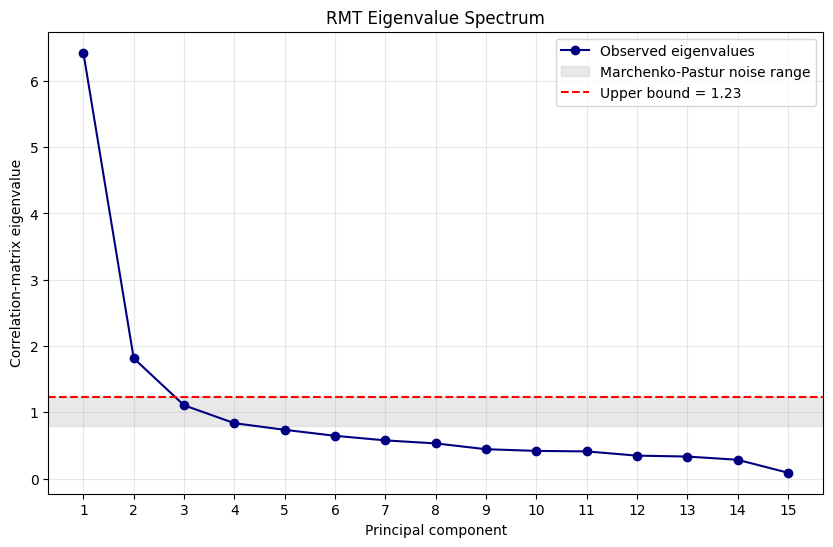

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(
    eigenvalue_table["Component"],
    eigenvalue_table["Eigenvalue"],
    marker="o",
    linestyle="-",
    color="navy",
    label="Observed eigenvalues"
)

plt.axhspan(
    lambda_minus,
    lambda_plus,
    color="lightgrey",
    alpha=0.5,
    label="Marchenko-Pastur noise range"
)

plt.axhline(
    lambda_plus,
    color="red",
    linestyle="--",
    label=f"Upper bound = {lambda_plus:.2f}"
)

plt.xlabel("Principal component")
plt.ylabel("Correlation-matrix eigenvalue")
plt.title("RMT Eigenvalue Spectrum")
plt.xticks(range(1, N + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

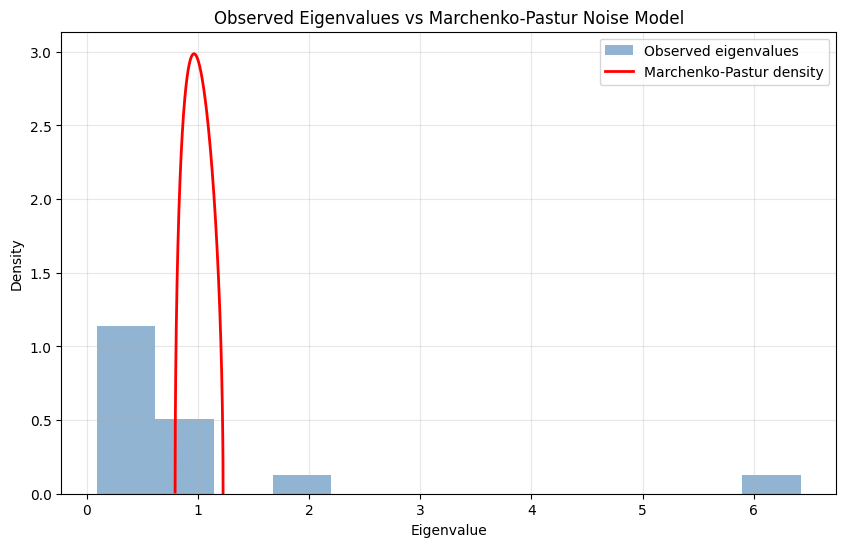

In [44]:
lambda_grid = np.linspace(
    lambda_minus + 1e-6,
    lambda_plus - 1e-6,
    500
)

mp_density = (
    np.sqrt((lambda_plus - lambda_grid) * (lambda_grid - lambda_minus))
    / (2 * np.pi * q * lambda_grid)
)

plt.figure(figsize=(10, 6))

plt.hist(
    eigenvalues,
    bins=min(N, 12),
    density=True,
    alpha=0.6,
    color="steelblue",
    label="Observed eigenvalues"
)

plt.plot(
    lambda_grid,
    mp_density,
    color="red",
    linewidth=2,
    label="Marchenko-Pastur density"
)

plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.title("Observed Eigenvalues vs Marchenko-Pastur Noise Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [45]:
signal_components = eigenvalue_table[
    eigenvalue_table["Above MP upper bound"]
]

print("Components above the Marchenko-Pastur upper bound:")
display(signal_components)

Components above the Marchenko-Pastur upper bound:


,Component,Eigenvalue,Explained variance (%),Above MP upper bound
0,1,6.424078,42.827186,True
1,2,1.815524,12.103492,True


In [29]:
# Ledoit-Wolf covariance estimator
lw_model = LedoitWolf().fit(daily_returns.to_numpy())
num_assets = len(annual_returns)

# Annualise and restore ticker labels
lw_annual_cov = pd.DataFrame(
    lw_model.covariance_ * TRADING_DAYS,
    index=annual_returns.index,
    columns=annual_returns.index
)

# Numerical comparison of covariance estimates
sample_cov_array = annual_cov.to_numpy()
lw_cov_array = lw_annual_cov.to_numpy()

covariance_comparison = pd.DataFrame({
    "Sample covariance": [
        np.linalg.cond(sample_cov_array),
        np.mean(np.diag(sample_cov_array)),
        np.mean(sample_cov_array[np.triu_indices(num_assets, k=1)])
    ],
    "Ledoit-Wolf covariance": [
        np.linalg.cond(lw_cov_array),
        np.mean(np.diag(lw_cov_array)),
        np.mean(lw_cov_array[np.triu_indices(num_assets, k=1)])
    ]
}, index=[
    "Condition number",
    "Average variance",
    "Average pairwise covariance"
])

print(f"Ledoit-Wolf shrinkage intensity: {lw_model.shrinkage_:.4f}")
display(covariance_comparison)

Ledoit-Wolf shrinkage intensity: 0.0192


,Sample covariance,Ledoit-Wolf covariance
Condition number,132.437336,94.788923
Average variance,0.151535,0.151418
Average pairwise covariance,0.040575,0.039764


/var/folders/22/3q6903ns1bz_vpy7hj829d100000gn/T/ipykernel_23492/1064253031.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


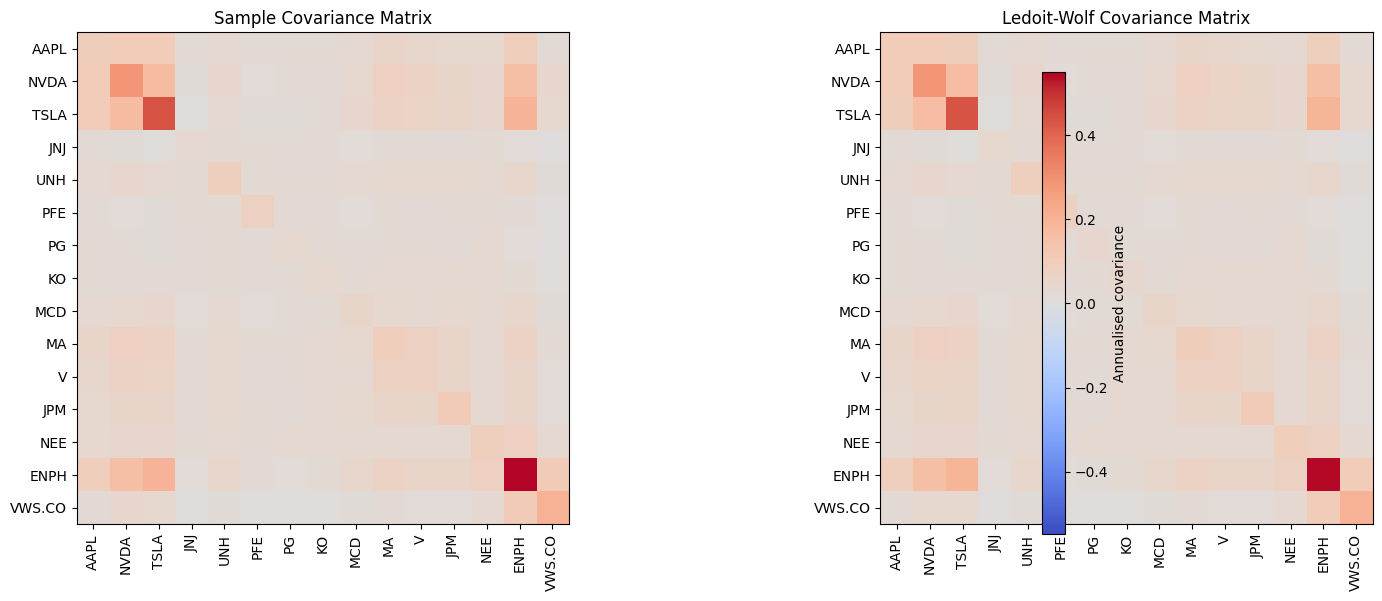

In [30]:
# Visual comparison of covariance matrices
limit = max(
    np.abs(sample_cov_array).max(),
    np.abs(lw_cov_array).max()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample_plot = axes[0].imshow(
    sample_cov_array,
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit
)
axes[0].set_title("Sample Covariance Matrix")
axes[0].set_xticks(range(num_assets))
axes[0].set_yticks(range(num_assets))
axes[0].set_xticklabels(annual_returns.index, rotation=90)
axes[0].set_yticklabels(annual_returns.index)

axes[1].imshow(
    lw_cov_array,
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit
)
axes[1].set_title("Ledoit-Wolf Covariance Matrix")
axes[1].set_xticks(range(num_assets))
axes[1].set_yticks(range(num_assets))
axes[1].set_xticklabels(annual_returns.index, rotation=90)
axes[1].set_yticklabels(annual_returns.index)

fig.colorbar(sample_plot, ax=axes, label="Annualised covariance")
plt.tight_layout()
plt.show()

4) Simulate only feasible portfolios

In [31]:
num_portfolios = 100_000
rng = np.random.default_rng(RANDOM_SEED)

num_assets = len(annual_returns)

# Long-only weights that sum to 1
weights_matrix = rng.dirichlet(np.ones(num_assets), size=num_portfolios)

simulated_esg = weights_matrix @ esg_scores.to_numpy()

# Apply the same constraints used by the optimizer
feasible = (
    (weights_matrix.max(axis=1) <= MAX_WEIGHT) &
    (simulated_esg >= MIN_ESG_SCORE)
)

weights_matrix = weights_matrix[feasible]
simulated_esg = simulated_esg[feasible]

simulated_returns = weights_matrix @ annual_returns.to_numpy()
simulated_risks = np.sqrt(
    np.einsum("ij,jk,ik->i", weights_matrix, annual_cov.to_numpy(), weights_matrix)
)

results_df = pd.DataFrame({
    "Return": simulated_returns,
    "Risk": simulated_risks,
    "ESG": simulated_esg
})

print(f"Feasible simulated portfolios: {len(results_df):,}")

Feasible simulated portfolios: 20,259


5) Plot the Portfolio Cloud 

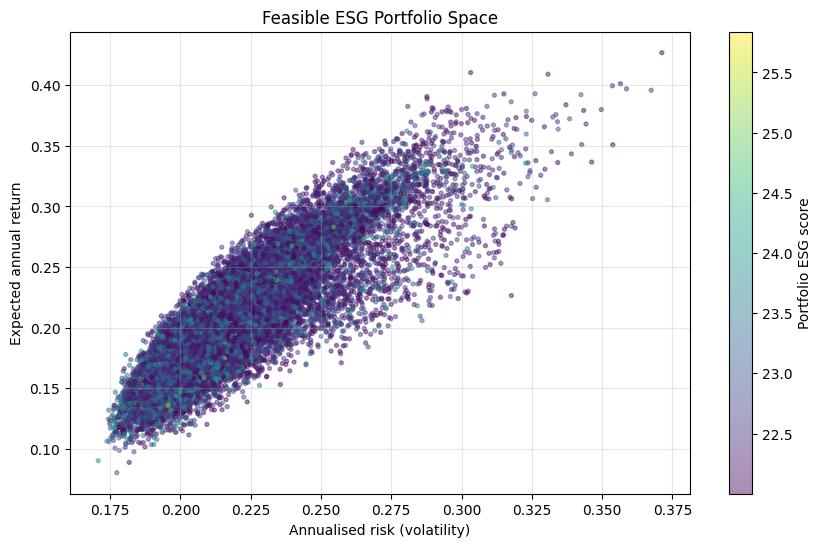

In [32]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    results_df["Risk"],
    results_df["Return"],
    c=results_df["ESG"],
    cmap="viridis",
    alpha=0.45,
    s=8
)

plt.colorbar(scatter, label="Portfolio ESG score")
plt.xlabel("Annualised risk (volatility)")
plt.ylabel("Expected annual return")
plt.title("Feasible ESG Portfolio Space")
plt.grid(True, alpha=0.3)
plt.show()

6) Optimise the Portfolio

In [33]:
returns_array = annual_returns.to_numpy()
cov_array = annual_cov.to_numpy()
esg_array = esg_scores.to_numpy()

def portfolio_risk(weights, covariance_matrix):
    return np.sqrt(weights @ covariance_matrix @ weights)

def objective(weights, expected_returns, covariance_matrix):
    portfolio_return = weights @ expected_returns
    risk = portfolio_risk(weights, covariance_matrix)

    # Maximise return while penalising volatility
    return -(portfolio_return - RISK_AVERSION * risk)

constraints = [
    {"type": "eq", "fun": lambda w: w.sum() - 1},
    {"type": "ineq", "fun": lambda w: w @ esg_array - MIN_ESG_SCORE}
]

# MAX_WEIGHT belongs in bounds, not as np.max(weights) inside a constraint
bounds = [(0, MAX_WEIGHT)] * num_assets
initial_weights = np.repeat(1 / num_assets, num_assets)

result = minimize(
    objective,
    initial_weights,
    args=(returns_array, cov_array),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 1_000}
)

if not result.success:
    raise RuntimeError(f"Optimisation failed: {result.message}")

optimal_weights = result.x
opt_return = optimal_weights @ returns_array
opt_risk = portfolio_risk(optimal_weights, cov_array)
opt_esg = optimal_weights @ esg_array

optimal_portfolio = pd.DataFrame({
    "Ticker": annual_returns.index,
    "Weight": optimal_weights,
    "ESG Score": esg_array,
    "Expected Annual Return": returns_array
}).query("Weight > 1e-6").sort_values("Weight", ascending=False)

print(f"Expected annual return: {opt_return:.2%}")
print(f"Annualised risk: {opt_risk:.2%}")
print(f"Portfolio ESG score: {opt_esg:.2f}")
display(optimal_portfolio)

Expected annual return: 52.10%
Annualised risk: 37.07%
Portfolio ESG score: 22.00


,Ticker,Weight,ESG Score,Expected Annual Return
2,TSLA,0.300000,24.8,0.736024
1,NVDA,0.300000,12.5,0.748906
11,JPM,0.300000,27.3,0.183123
8,MCD,0.073256,28.5,0.121058
13,ENPH,0.026744,19.9,0.438319


In [34]:
# Preserve the original sample-covariance portfolio
sample_weights = optimal_weights.copy()
sample_return = opt_return
sample_risk = opt_risk
sample_esg = opt_esg

# Optimise again using Ledoit-Wolf covariance
lw_result = minimize(
    objective,
    initial_weights,
    args=(returns_array, lw_cov_array),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 1_000}
)

if not lw_result.success:
    raise RuntimeError(f"Ledoit-Wolf optimisation failed: {lw_result.message}")

lw_weights = lw_result.x
lw_return = lw_weights @ returns_array
lw_risk = portfolio_risk(lw_weights, lw_cov_array)
lw_esg = lw_weights @ esg_array

portfolio_comparison = pd.DataFrame({
    "Sample covariance": [
        sample_return,
        sample_risk,
        sample_esg,
        sample_weights.max()
    ],
    "Ledoit-Wolf covariance": [
        lw_return,
        lw_risk,
        lw_esg,
        lw_weights.max()
    ]
}, index=[
    "Expected annual return",
    "Estimated annual risk",
    "Portfolio ESG score",
    "Largest stock weight"
])

display(portfolio_comparison.style.format({
    "Sample covariance": "{:.4f}",
    "Ledoit-Wolf covariance": "{:.4f}"
}))

,Sample covariance,Ledoit-Wolf covariance
Expected annual return,0.5210,0.5210
Estimated annual risk,0.3707,0.3680
Portfolio ESG score,22.0000,22.0000
Largest stock weight,0.3000,0.3000


In [38]:
# CVXPY optimisation using the Ledoit-Wolf covariance matrix

# Make the covariance matrix exactly symmetric and positive semidefinite
lw_cov_symmetric = (lw_cov_array + lw_cov_array.T) / 2

eigenvalues, eigenvectors = np.linalg.eigh(lw_cov_symmetric)
eigenvalues = np.clip(eigenvalues, 0, None)

# Risk factor lets CVXPY express volatility as a convex norm
risk_factor = eigenvectors @ np.diag(np.sqrt(eigenvalues))

# Decision variable: one portfolio weight per asset
cvx_weights_variable = cp.Variable(num_assets)

# Portfolio expressions
cvx_return_expression = returns_array @ cvx_weights_variable
cvx_risk_expression = cp.norm(risk_factor.T @ cvx_weights_variable, 2)
cvx_esg_expression = esg_array @ cvx_weights_variable

# Same objective as the existing SLSQP model
cvx_objective = cp.Maximize(
    cvx_return_expression - RISK_AVERSION * cvx_risk_expression
)

# Same portfolio constraints
cvx_constraints = [
    cp.sum(cvx_weights_variable) == 1,
    cvx_weights_variable >= 0,
    cvx_weights_variable <= MAX_WEIGHT,
    cvx_esg_expression >= MIN_ESG_SCORE
]

cvx_problem = cp.Problem(cvx_objective, cvx_constraints)

assert cvx_problem.is_dcp(), "The CVXPY problem is not convex."

# Use a suitable installed solver
available_solvers = cp.installed_solvers()
solver = "CLARABEL" if "CLARABEL" in available_solvers else "SCS"

cvx_problem.solve(solver=solver, verbose=False)

if cvx_problem.status not in ["optimal", "optimal_inaccurate"]:
    raise RuntimeError(f"CVXPY optimisation failed: {cvx_problem.status}")

cvx_weights = np.asarray(cvx_weights_variable.value).ravel()
cvx_return = cvx_weights @ returns_array
cvx_risk = portfolio_risk(cvx_weights, lw_cov_array)
cvx_esg = cvx_weights @ esg_array

print("----- CVXPY + LEDOIT-WOLF OPTIMAL PORTFOLIO -----")
print(f"Solver: {solver}")
print(f"Status: {cvx_problem.status}")
print(f"Expected annual return: {cvx_return:.2%}")
print(f"Annualised risk: {cvx_risk:.2%}")
print(f"Portfolio ESG score: {cvx_esg:.2f}")
print(f"Largest stock weight: {cvx_weights.max():.2%}")

----- CVXPY + LEDOIT-WOLF OPTIMAL PORTFOLIO -----
Solver: CLARABEL
Status: optimal
Expected annual return: 52.10%
Annualised risk: 36.80%
Portfolio ESG score: 22.00
Largest stock weight: 30.00%


In [46]:
# Wasserstein Distributionally Robust Optimisation (DRO)
# Uses annual-return units throughout.

WASSERSTEIN_RADIUS = 0.02

# Recreate a stable covariance risk factor from Ledoit-Wolf covariance
lw_cov_symmetric = (lw_cov_array + lw_cov_array.T) / 2

eigenvalues, eigenvectors = np.linalg.eigh(lw_cov_symmetric)
eigenvalues = np.clip(eigenvalues, 0, None)

risk_factor = eigenvectors @ np.diag(np.sqrt(eigenvalues))

# Portfolio-weight decision variable
dro_weights_variable = cp.Variable(num_assets)

# Expected return and Ledoit-Wolf volatility
dro_return_expression = returns_array @ dro_weights_variable
dro_risk_expression = cp.norm(risk_factor.T @ dro_weights_variable, 2)

# Wasserstein robustness penalty:
# protects against uncertainty in estimated expected returns
dro_penalty_expression = WASSERSTEIN_RADIUS * cp.norm(
    dro_weights_variable,
    2
)

# Robust objective: maximise worst-case expected return minus risk
dro_objective = cp.Maximize(
    dro_return_expression
    - RISK_AVERSION * dro_risk_expression
    - dro_penalty_expression
)

# Same ESG and allocation constraints as every other model
dro_constraints = [
    cp.sum(dro_weights_variable) == 1,
    dro_weights_variable >= 0,
    dro_weights_variable <= MAX_WEIGHT,
    esg_array @ dro_weights_variable >= MIN_ESG_SCORE
]

dro_problem = cp.Problem(dro_objective, dro_constraints)

assert dro_problem.is_dcp(), "DRO problem is not convex."

available_solvers = cp.installed_solvers()
solver = "CLARABEL" if "CLARABEL" in available_solvers else "SCS"

dro_problem.solve(solver=solver, verbose=False)

if dro_problem.status not in ["optimal", "optimal_inaccurate"]:
    raise RuntimeError(f"DRO optimisation failed: {dro_problem.status}")

dro_weights = np.asarray(dro_weights_variable.value).ravel()
dro_return = dro_weights @ returns_array
dro_risk = portfolio_risk(dro_weights, lw_cov_array)
dro_esg = dro_weights @ esg_array
dro_worst_case_return = dro_return - WASSERSTEIN_RADIUS * np.linalg.norm(dro_weights)

print("----- WASSERSTEIN DRO PORTFOLIO -----")
print(f"Wasserstein radius: {WASSERSTEIN_RADIUS:.2%}")
print(f"Expected annual return: {dro_return:.2%}")
print(f"Worst-case annual return: {dro_worst_case_return:.2%}")
print(f"Annualised risk: {dro_risk:.2%}")
print(f"Portfolio ESG score: {dro_esg:.2f}")
print(f"Largest stock weight: {dro_weights.max():.2%}")

----- WASSERSTEIN DRO PORTFOLIO -----
Wasserstein radius: 2.00%
Expected annual return: 52.01%
Worst-case annual return: 51.00%
Annualised risk: 36.65%
Portfolio ESG score: 22.00
Largest stock weight: 30.00%


In [47]:
robustness_comparison = pd.DataFrame({
    "CVXPY + Ledoit-Wolf": [
        cvx_return,
        cvx_risk,
        cvx_esg,
        cvx_weights.max()
    ],
    "Wasserstein DRO": [
        dro_return,
        dro_risk,
        dro_esg,
        dro_weights.max()
    ]
}, index=[
    "Expected annual return",
    "Annualised risk",
    "Portfolio ESG score",
    "Largest stock weight"
])

display(robustness_comparison.style.format("{:.4f}"))

,CVXPY + Ledoit-Wolf,Wasserstein DRO
Expected annual return,0.5210,0.5201
Annualised risk,0.3680,0.3665
Portfolio ESG score,22.0000,22.0000
Largest stock weight,0.3000,0.3000


In [48]:
radii = [0.00, 0.01, 0.02, 0.03, 0.05]
sensitivity_results = []

for epsilon in radii:
    weights_variable = cp.Variable(num_assets)

    objective = cp.Maximize(
        returns_array @ weights_variable
        - RISK_AVERSION * cp.norm(risk_factor.T @ weights_variable, 2)
        - epsilon * cp.norm(weights_variable, 2)
    )

    constraints = [
        cp.sum(weights_variable) == 1,
        weights_variable >= 0,
        weights_variable <= MAX_WEIGHT,
        esg_array @ weights_variable >= MIN_ESG_SCORE
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=solver, verbose=False)

    weights = np.asarray(weights_variable.value).ravel()

    sensitivity_results.append({
        "Wasserstein radius": epsilon,
        "Expected annual return": weights @ returns_array,
        "Annualised risk": portfolio_risk(weights, lw_cov_array),
        "Portfolio ESG score": weights @ esg_array,
        "Weight concentration": np.linalg.norm(weights),
        "Largest weight": weights.max()
    })

dro_sensitivity_df = pd.DataFrame(sensitivity_results)
display(dro_sensitivity_df.style.format({
    "Wasserstein radius": "{:.2%}",
    "Expected annual return": "{:.2%}",
    "Annualised risk": "{:.2%}",
    "Portfolio ESG score": "{:.2f}",
    "Weight concentration": "{:.4f}",
    "Largest weight": "{:.2%}"
}))

,Wasserstein radius,Expected annual return,Annualised risk,Portfolio ESG score,Weight concentration,Largest weight
0,0.00%,52.10%,36.80%,22.00,0.5250,30.00%
1,1.00%,52.04%,36.70%,22.00,0.5130,30.00%
2,2.00%,52.01%,36.65%,22.00,0.5070,30.00%
3,3.00%,51.99%,36.62%,22.00,0.5035,30.00%
4,5.00%,51.96%,36.59%,22.00,0.4999,30.00%


In [39]:
solver_comparison = pd.DataFrame({
    "SLSQP + Sample covariance": [
        sample_return,
        sample_risk,
        sample_esg
    ],
    "SLSQP + Ledoit-Wolf": [
        lw_return,
        lw_risk,
        lw_esg
    ],
    "CVXPY + Ledoit-Wolf": [
        cvx_return,
        cvx_risk,
        cvx_esg
    ]
}, index=[
    "Expected annual return",
    "Annualised risk",
    "Portfolio ESG score"
])

display(solver_comparison.style.format("{:.4f}"))

,SLSQP + Sample covariance,SLSQP + Ledoit-Wolf,CVXPY + Ledoit-Wolf
Expected annual return,0.5210,0.5210,0.5210
Annualised risk,0.3707,0.3680,0.3680
Portfolio ESG score,22.0000,22.0000,22.0000


,Sample covariance,Ledoit-Wolf covariance
Ticker,,
TSLA,30.00%,30.00%
NVDA,30.00%,30.00%
JPM,30.00%,29.86%
MCD,7.33%,7.44%
ENPH,2.67%,2.69%
VWS.CO,0.00%,0.00%
PG,0.00%,0.00%
AAPL,0.00%,0.00%
JNJ,0.00%,0.00%


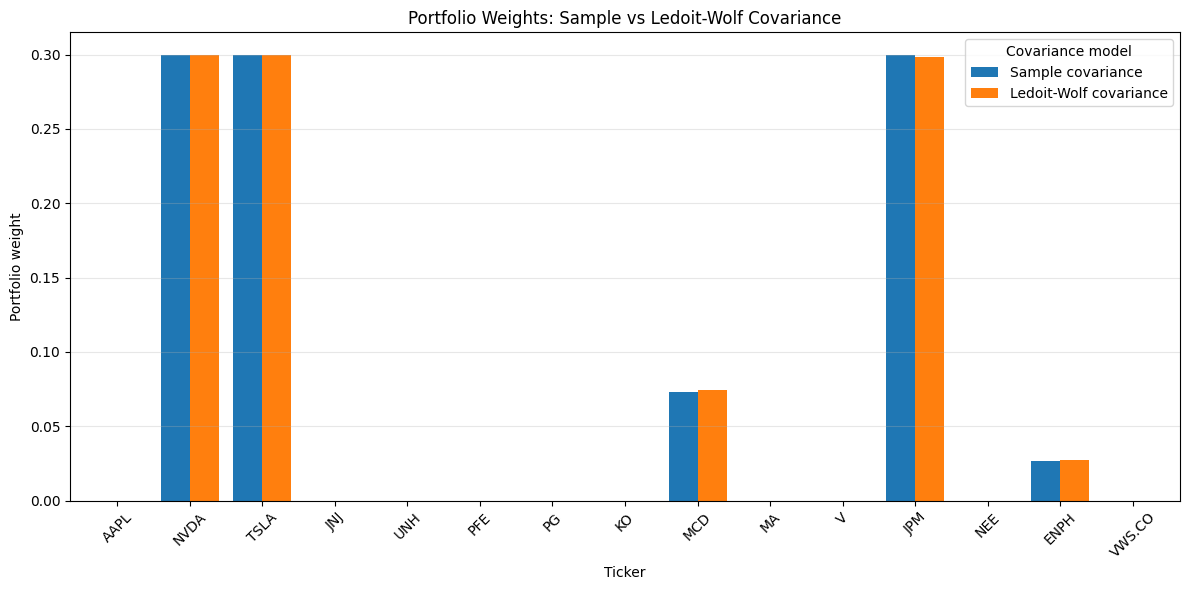

In [35]:
weight_comparison = pd.DataFrame({
    "Sample covariance": sample_weights,
    "Ledoit-Wolf covariance": lw_weights
}, index=annual_returns.index)

display(weight_comparison.sort_values(
    "Ledoit-Wolf covariance",
    ascending=False
).style.format("{:.2%}"))

weight_comparison.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.ylabel("Portfolio weight")
plt.title("Portfolio Weights: Sample vs Ledoit-Wolf Covariance")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Covariance model")
plt.tight_layout()
plt.show()

7) Final Comparision Plot 

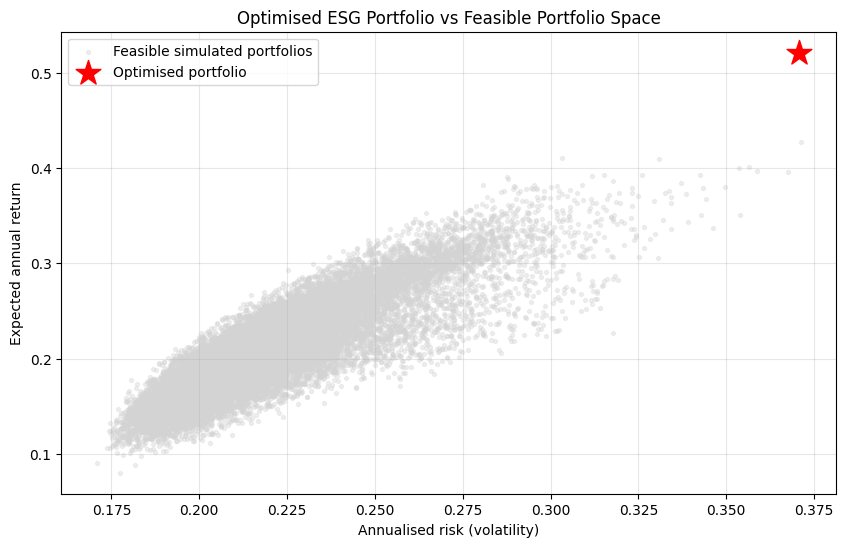

In [36]:
plt.figure(figsize=(10, 6))

plt.scatter(
    results_df["Risk"],
    results_df["Return"],
    color="lightgrey",
    alpha=0.35,
    s=8,
    label="Feasible simulated portfolios"
)

plt.scatter(
    opt_risk,
    opt_return,
    color="red",
    marker="*",
    s=350,
    label="Optimised portfolio"
)

plt.xlabel("Annualised risk (volatility)")
plt.ylabel("Expected annual return")
plt.title("Optimised ESG Portfolio vs Feasible Portfolio Space")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

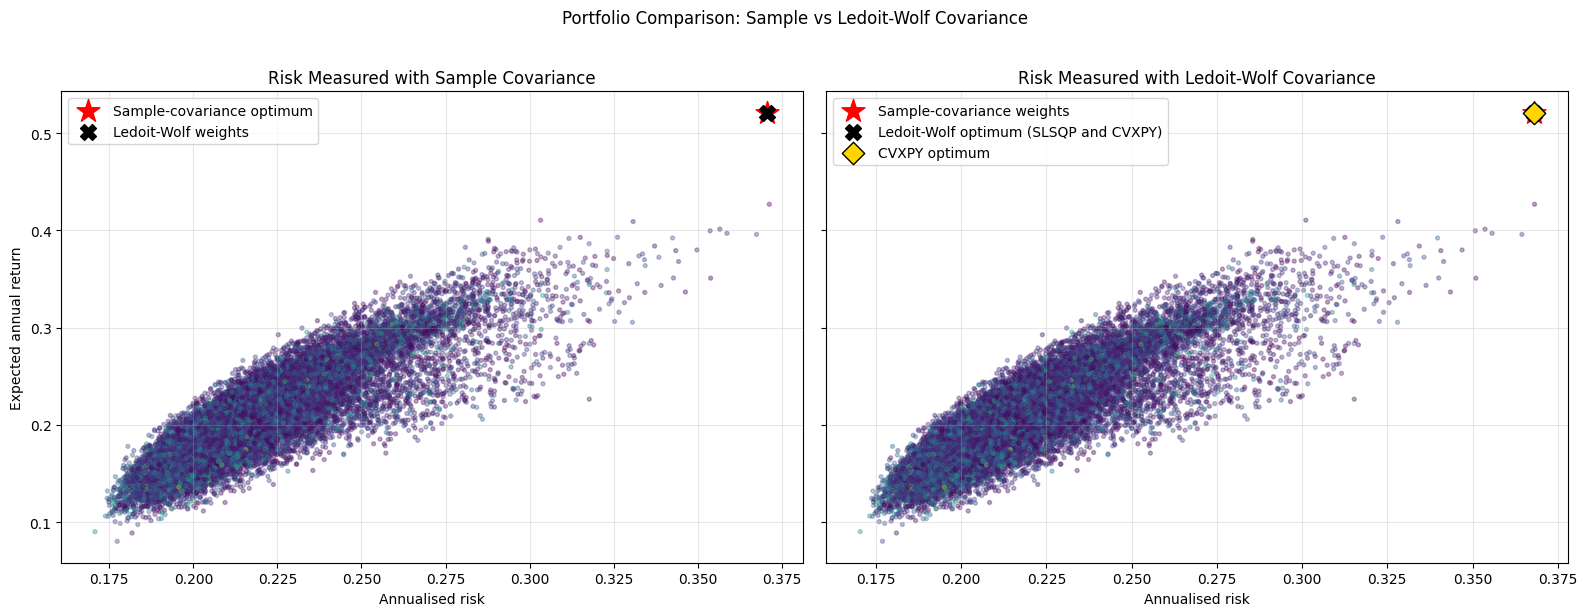

In [41]:
# Calculate simulated portfolio risks using Ledoit-Wolf covariance
lw_simulated_risks = np.sqrt(
    np.einsum("ij,jk,ik->i", weights_matrix, lw_cov_array, weights_matrix)
)

# Calculate each optimized portfolio's risk under both models
sample_risk_under_lw = portfolio_risk(sample_weights, lw_cov_array)
lw_risk_under_sample = portfolio_risk(lw_weights, sample_cov_array)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Sample covariance chart
axes[0].scatter(
    simulated_risks,
    simulated_returns,
    c=simulated_esg,
    cmap="viridis",
    alpha=0.35,
    s=8
)
axes[0].scatter(
    sample_risk,
    sample_return,
    color="red",
    marker="*",
    s=300,
    label="Sample-covariance optimum"
)
axes[0].scatter(
    lw_risk_under_sample,
    lw_return,
    color="black",
    marker="X",
    s=130,
    label="Ledoit-Wolf weights"
)
axes[0].set_title("Risk Measured with Sample Covariance")
axes[0].set_xlabel("Annualised risk")
axes[0].set_ylabel("Expected annual return")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Ledoit-Wolf covariance chart
axes[1].scatter(
    lw_simulated_risks,
    simulated_returns,
    c=simulated_esg,
    cmap="viridis",
    alpha=0.35,
    s=8
)
axes[1].scatter(
    sample_risk_under_lw,
    sample_return,
    color="red",
    marker="*",
    s=300,
    label="Sample-covariance weights"
)
axes[1].scatter(
    lw_risk,
    lw_return,
    color="black",
    marker="X",
    s=130,
    label="Ledoit-Wolf optimum (SLSQP and CVXPY)"
)
axes[1].scatter(
    cvx_risk,
    cvx_return,
    color="gold",
    edgecolor="black",
    marker="D",
    s=130,
    label="CVXPY optimum"
)
axes[1].set_title("Risk Measured with Ledoit-Wolf Covariance")
axes[1].set_xlabel("Annualised risk")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Portfolio Comparison: Sample vs Ledoit-Wolf Covariance", y=1.02)
plt.tight_layout()
plt.show()

## Extension: sensitivity analysis and out-of-sample validation

This section is self-contained. It loads its own prices and ESG scores, so it does not depend on earlier notebook variables or cell execution order.


Wasserstein-radius sensitivity


,Wasserstein Radius,Annualised Return,Annualised Volatility,Sharpe Ratio,Portfolio ESG Score,Maximum Weight,L2 Weight Norm,Active Holdings,Cumulative Return,Maximum Drawdown
0,0.00,0.5210,0.3706,1.4057,22.0,0.3,0.5250,5,9.0946,-0.4579
1,0.01,0.5204,0.3697,1.4078,22.0,0.3,0.5130,5,9.0851,-0.4537
2,0.02,0.5201,0.3692,1.4087,22.0,0.3,0.5070,5,9.0771,-0.4537
3,0.03,0.5199,0.3689,1.4092,22.0,0.3,0.5035,5,9.0707,-0.4538
4,0.05,0.5196,0.3686,1.4095,22.0,0.3,0.4999,5,9.0617,-0.4539



ESG-threshold sensitivity


,Minimum ESG Score,Annualised Return,Annualised Volatility,Sharpe Ratio,Portfolio ESG Score,Maximum Weight,L2 Weight Norm,Active Holdings,Cumulative Return,Maximum Drawdown
0,18.0,0.5898,0.4381,1.3463,18.9407,0.3,0.5101,4,11.4885,-0.4676
1,20.0,0.5750,0.4249,1.3535,20.0000,0.3,0.4875,5,10.9200,-0.4750
2,22.0,0.5201,0.3692,1.4087,22.0000,0.3,0.5070,5,9.0771,-0.4537
3,24.0,0.4420,0.3298,1.3402,24.0000,0.3,0.5067,4,6.2550,-0.4463
4,26.0,0.3627,0.3041,1.1928,26.0000,0.3,0.5248,5,4.0427,-0.4457



Risk-aversion sensitivity


,Risk Aversion,Annualised Return,Annualised Volatility,Sharpe Ratio,Portfolio ESG Score,Maximum Weight,L2 Weight Norm,Active Holdings,Cumulative Return,Maximum Drawdown
0,0.10,0.5210,0.3707,1.4056,22.0,0.3,0.5254,5,9.0948,-0.4580
1,0.25,0.5210,0.3707,1.4056,22.0,0.3,0.5253,5,9.0947,-0.4580
2,0.50,0.5201,0.3692,1.4087,22.0,0.3,0.5070,5,9.0771,-0.4537
3,0.75,0.5196,0.3687,1.4095,22.0,0.3,0.5008,6,9.0636,-0.4538
4,1.00,0.5008,0.3469,1.4437,22.0,0.3,0.4848,6,8.5159,-0.4449


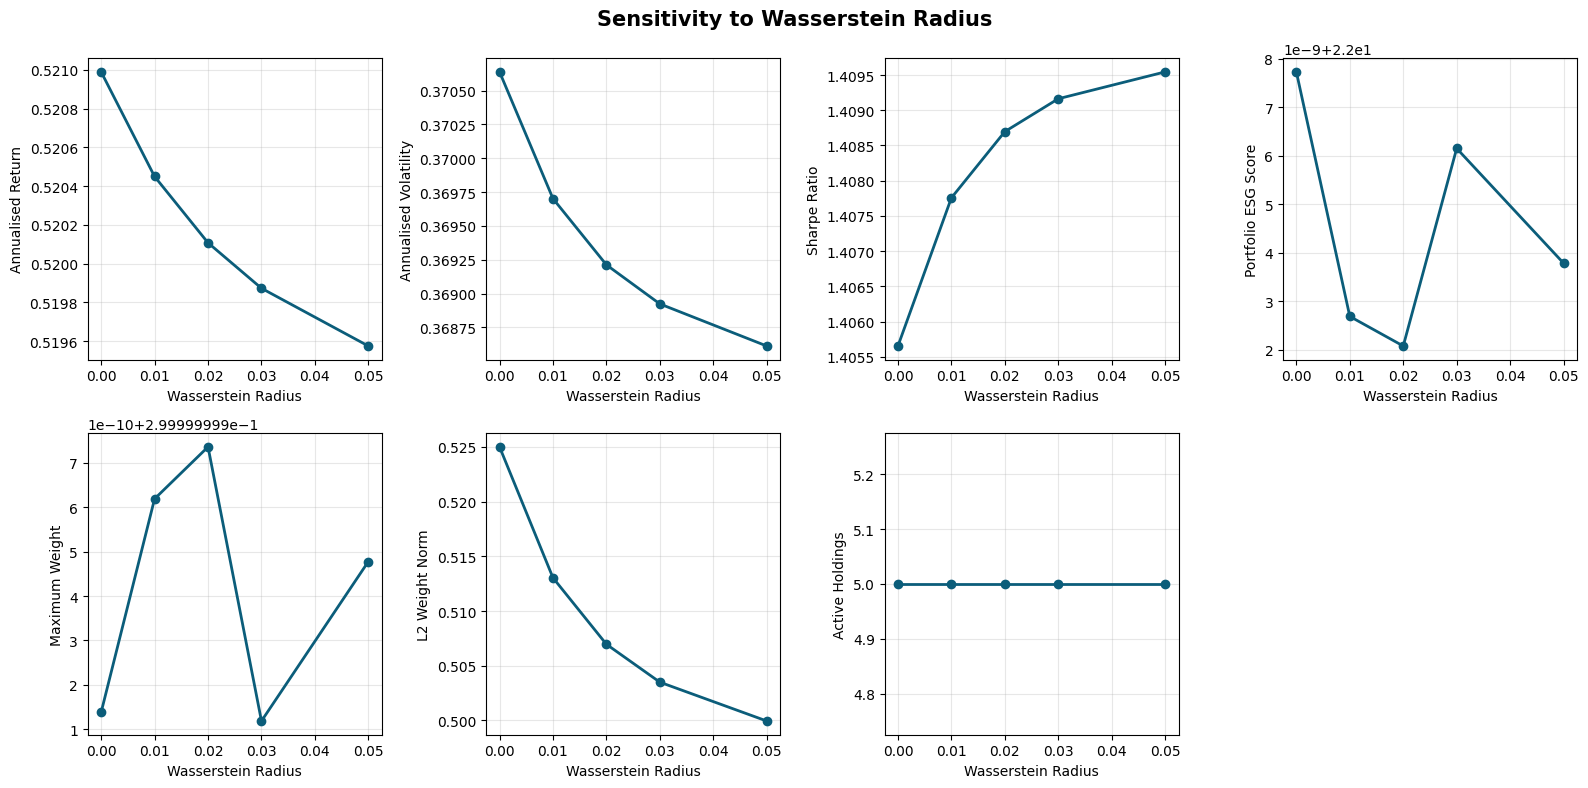

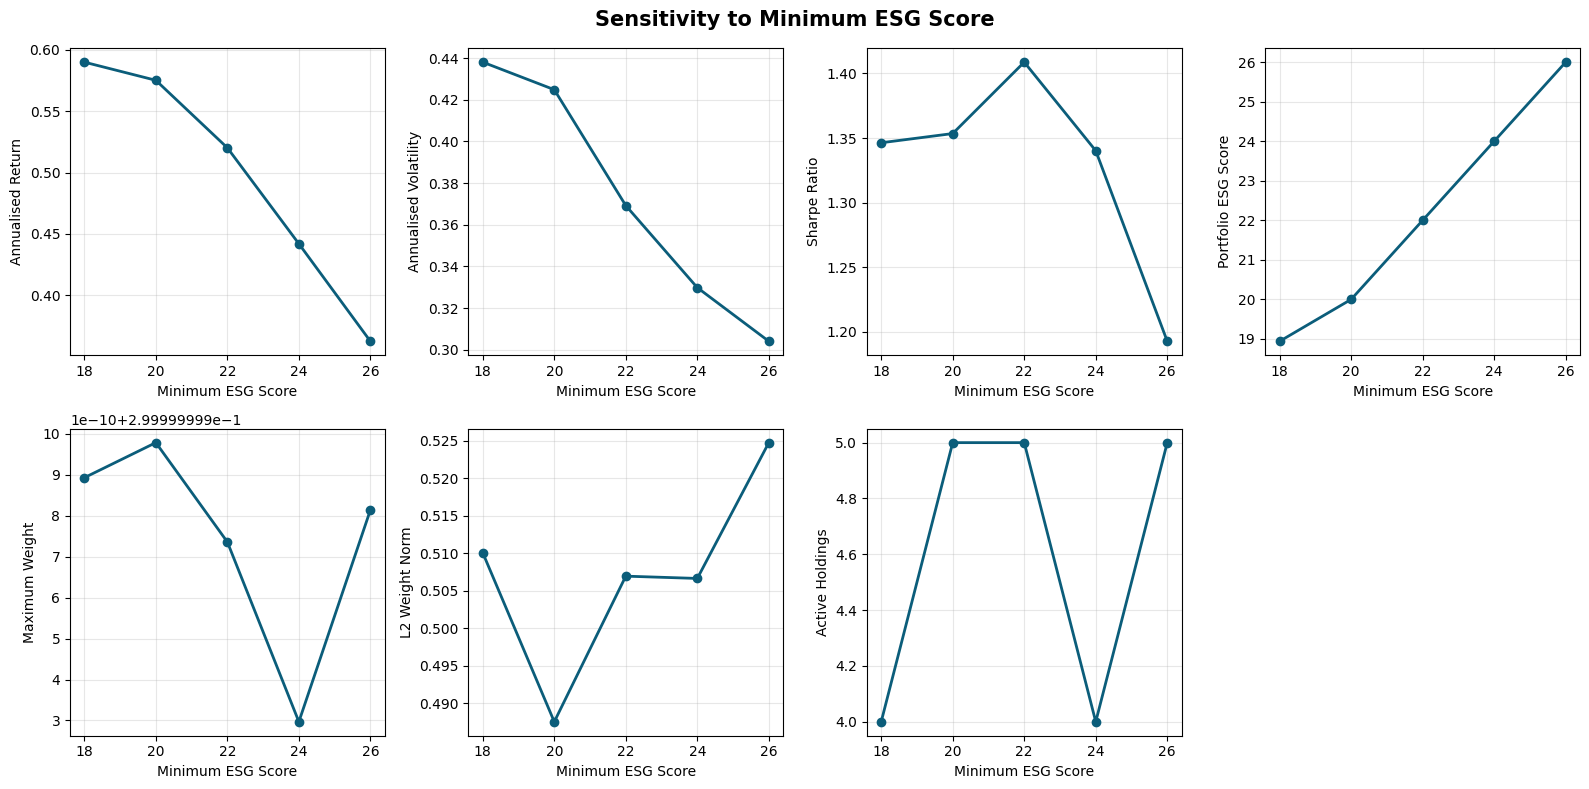

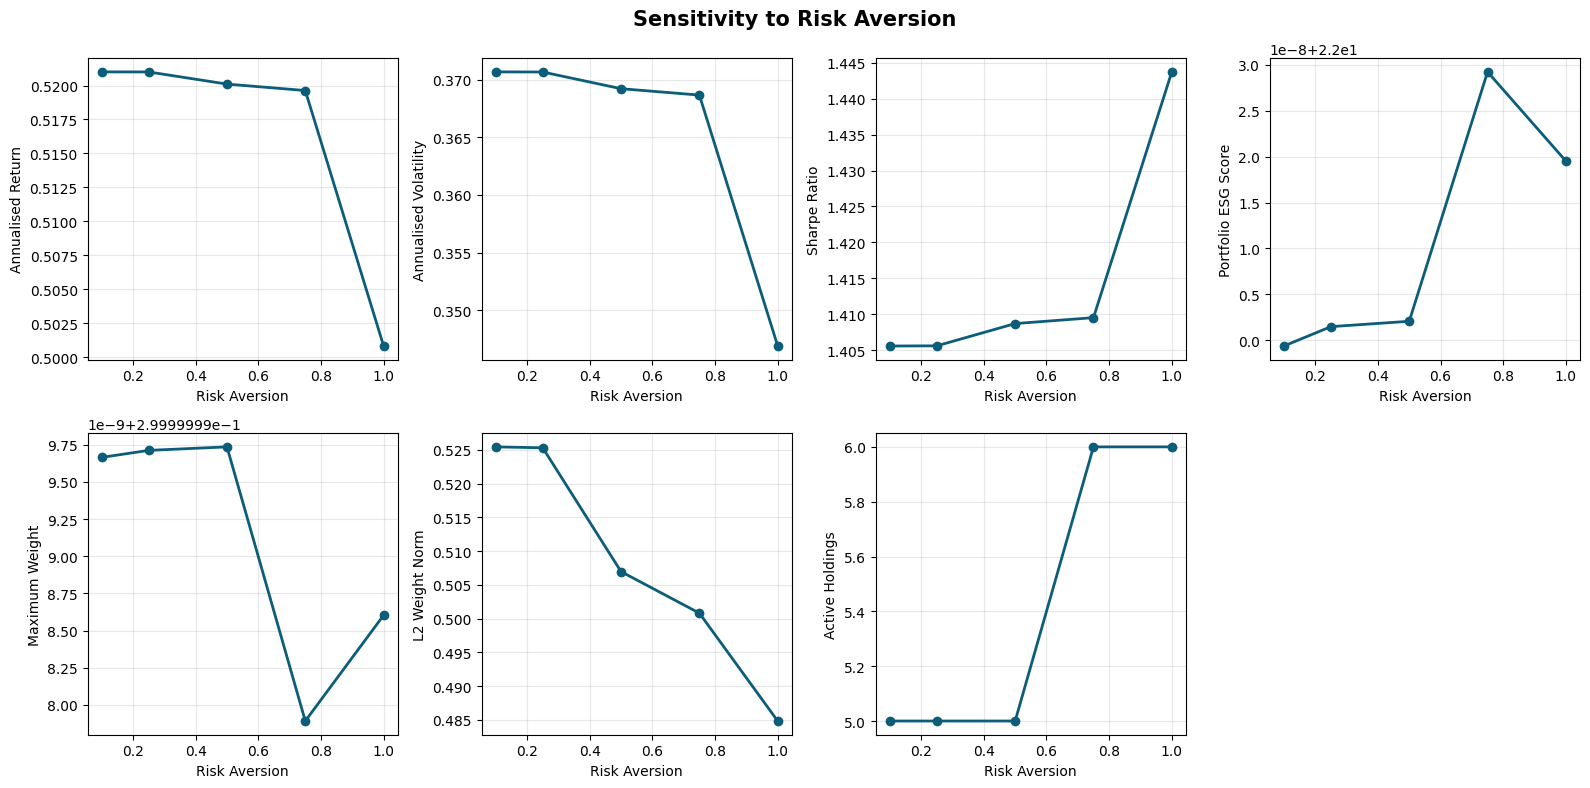


Out-of-sample performance (test period only; weights frozen after training)


,Annualised Return,Annualised Volatility,Sharpe Ratio,Portfolio ESG Score,Maximum Weight,L2 Weight Norm,Active Holdings,Cumulative Return,Maximum Drawdown
Sample Covariance,0.2723,0.3177,0.8572,22.0000,0.3000,0.5111,4.0,0.2552,-0.1605
Ledoit-Wolf,0.2723,0.3177,0.8572,22.0000,0.3000,0.5111,4.0,0.2552,-0.1605
Wasserstein DRO,0.2723,0.3177,0.8572,22.0000,0.3000,0.5111,4.0,0.2552,-0.1605
Equal Weight,0.1471,0.1203,1.2226,21.0267,0.0667,0.2582,15.0,0.1539,-0.0592


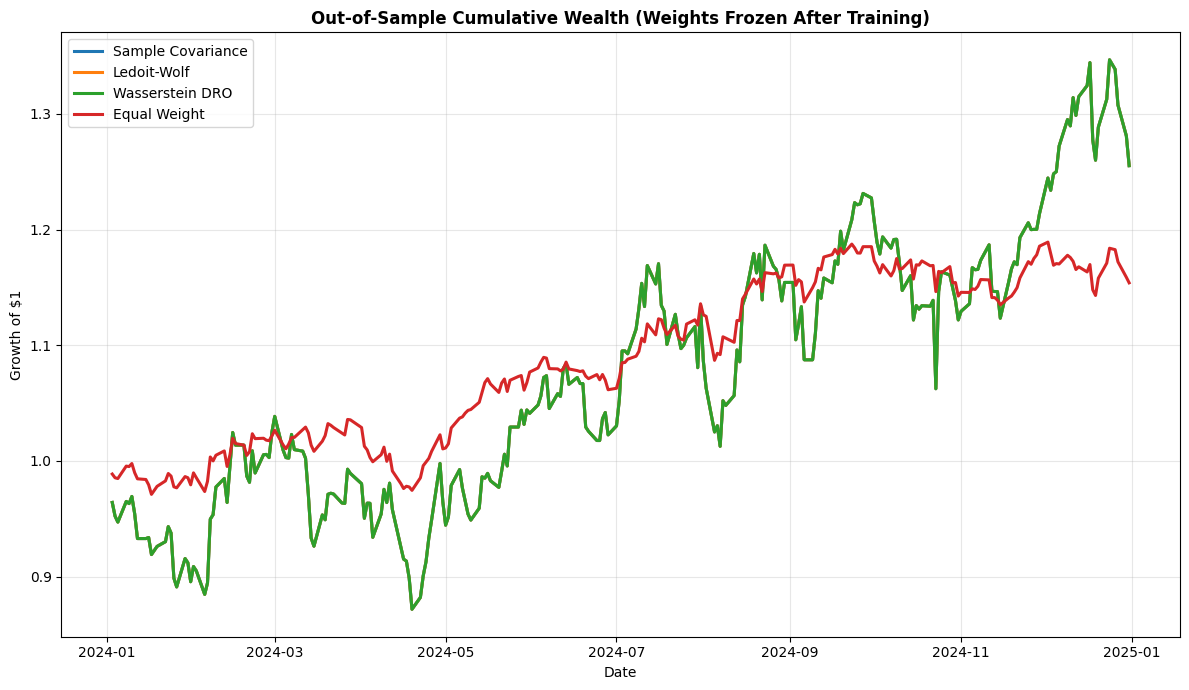

In [1]:
# SELF-CONTAINED EXTENSION — run this single cell after restarting the kernel.
# It does NOT use daily_returns, esg_scores, close_prices, or esg_df from earlier cells.

from pathlib import Path
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.covariance import LedoitWolf

EXT_TRADING_DAYS = 252
EXT_MAX_WEIGHT = 0.30
EXT_MIN_ESG_SCORE = 22.0
EXT_RISK_AVERSION = 0.50
EXT_WASSERSTEIN_RADIUS = 0.02

# ---------- Load and align data independently ----------
ext_price_file = Path('data/stock_prices_auto_adjusted.csv')
ext_esg_file = Path('data/ESGrisk.csv')
if not ext_price_file.exists() or not ext_esg_file.exists():
    raise FileNotFoundError('Run this notebook from the project root containing data/.')

ext_raw_prices = pd.read_csv(ext_price_file, header=[0, 1], index_col=0, parse_dates=True)
ext_close = ext_raw_prices['Close'].copy()
ext_close.columns = ext_close.columns.astype(str).str.strip()
ext_close = ext_close.sort_index().ffill().dropna(axis=1)

ext_esg_frame = pd.read_csv(ext_esg_file)
ext_esg_frame.columns = ext_esg_frame.columns.str.strip()
ext_esg_frame['Ticker'] = ext_esg_frame['Ticker'].astype(str).str.strip()
ext_esg_frame['ESG Score'] = pd.to_numeric(ext_esg_frame['ESG Score'], errors='coerce')
ext_esg = (ext_esg_frame.dropna(subset=['Ticker', 'ESG Score'])
           .drop_duplicates('Ticker').set_index('Ticker')['ESG Score'])
ext_tickers = ext_close.columns.intersection(ext_esg.index, sort=False)
ext_close = ext_close.loc[:, ext_tickers]
ext_esg = ext_esg.loc[ext_tickers]
ext_returns = ext_close.pct_change(fill_method=None).dropna(how='any')
if len(ext_returns) < 30 or len(ext_returns.columns) < 2:
    raise ValueError('Not enough aligned assets or return observations for optimisation.')

# ---------- Optimisation and evaluation helpers ----------
def ext_solver_name():
    for name in ('CLARABEL', 'SCS'):
        if name in cp.installed_solvers():
            return name
    raise RuntimeError('Install a CVXPY conic solver such as CLARABEL or SCS.')

def ext_inputs(returns, covariance_type):
    mu = returns.mean().to_numpy() * EXT_TRADING_DAYS
    if covariance_type == 'sample':
        sigma = returns.cov().to_numpy() * EXT_TRADING_DAYS
    elif covariance_type == 'ledoit_wolf':
        sigma = LedoitWolf().fit(returns.to_numpy()).covariance_ * EXT_TRADING_DAYS
    else:
        raise ValueError("covariance_type must be 'sample' or 'ledoit_wolf'.")
    return mu, sigma

def ext_solve(returns, covariance_type='ledoit_wolf', epsilon=0.0,
              min_esg=EXT_MIN_ESG_SCORE, risk_aversion=EXT_RISK_AVERSION):
    mu, sigma = ext_inputs(returns, covariance_type)
    sigma = (sigma + sigma.T) / 2
    values, vectors = np.linalg.eigh(sigma)
    factor = vectors @ np.diag(np.sqrt(np.clip(values, 0, None)))
    w = cp.Variable(returns.shape[1])
    volatility = cp.norm(factor.T @ w, 2)
    objective = mu @ w - risk_aversion * volatility - epsilon * cp.norm(w, 2)
    constraints = [cp.sum(w) == 1, w >= 0, w <= EXT_MAX_WEIGHT,
                   ext_esg.loc[returns.columns].to_numpy() @ w >= min_esg]
    problem = cp.Problem(cp.Maximize(objective), constraints)
    problem.solve(solver=ext_solver_name(), verbose=False)
    if problem.status not in ('optimal', 'optimal_inaccurate'):
        raise RuntimeError(f'Optimisation failed: {problem.status}. Check the ESG threshold is feasible.')
    return pd.Series(np.asarray(w.value).ravel(), index=returns.columns, name='Weight')

def ext_metrics(weights, returns):
    portfolio_returns = returns @ weights
    annual_return = portfolio_returns.mean() * EXT_TRADING_DAYS
    annual_volatility = portfolio_returns.std(ddof=1) * np.sqrt(EXT_TRADING_DAYS)
    wealth = (1 + portfolio_returns).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    return {'Annualised Return': annual_return,
            'Annualised Volatility': annual_volatility,
            'Sharpe Ratio': annual_return / annual_volatility,
            'Portfolio ESG Score': weights @ ext_esg.loc[weights.index],
            'Maximum Weight': weights.max(),
            'L2 Weight Norm': np.linalg.norm(weights.to_numpy()),
            'Active Holdings': int((weights > 1e-6).sum()),
            'Cumulative Return': wealth.iloc[-1] - 1,
            'Maximum Drawdown': drawdown.min()}

# ---------- One-way sensitivity analyses ----------
def ext_sensitivity(column, values):
    rows = []
    for value in values:
        epsilon = EXT_WASSERSTEIN_RADIUS
        min_esg = EXT_MIN_ESG_SCORE
        risk_aversion = EXT_RISK_AVERSION
        if column == 'Wasserstein Radius': epsilon = value
        elif column == 'Minimum ESG Score': min_esg = value
        elif column == 'Risk Aversion': risk_aversion = value
        weights = ext_solve(ext_returns, epsilon=epsilon, min_esg=min_esg, risk_aversion=risk_aversion)
        rows.append({column: value, **ext_metrics(weights, ext_returns)})
    return pd.DataFrame(rows)

ext_epsilon_sensitivity = ext_sensitivity('Wasserstein Radius', [0.00, 0.01, 0.02, 0.03, 0.05])
ext_esg_sensitivity = ext_sensitivity('Minimum ESG Score', [18.0, 20.0, 22.0, 24.0, 26.0])
ext_lambda_sensitivity = ext_sensitivity('Risk Aversion', [0.10, 0.25, 0.50, 0.75, 1.00])

for title, table in [('Wasserstein-radius sensitivity', ext_epsilon_sensitivity),
                     ('ESG-threshold sensitivity', ext_esg_sensitivity),
                     ('Risk-aversion sensitivity', ext_lambda_sensitivity)]:
    print('\n' + title)
    display(table.round(4))

# Publication-quality sensitivity plots
def ext_plot_sensitivity(table, x_column, title):
    metrics = ['Annualised Return', 'Annualised Volatility', 'Sharpe Ratio',
               'Portfolio ESG Score', 'Maximum Weight', 'L2 Weight Norm', 'Active Holdings']
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for axis, metric in zip(axes.flat, metrics):
        axis.plot(table[x_column], table[metric], marker='o', color='#0B5D7A', linewidth=2)
        axis.set_xlabel(x_column)
        axis.set_ylabel(metric)
        axis.grid(alpha=0.3)
    axes.flat[-1].axis('off')
    fig.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

ext_plot_sensitivity(ext_epsilon_sensitivity, 'Wasserstein Radius', 'Sensitivity to Wasserstein Radius')
ext_plot_sensitivity(ext_esg_sensitivity, 'Minimum ESG Score', 'Sensitivity to Minimum ESG Score')
ext_plot_sensitivity(ext_lambda_sensitivity, 'Risk Aversion', 'Sensitivity to Risk Aversion')

# ---------- Strict chronological out-of-sample validation ----------
ext_split = int(len(ext_returns) * 0.80)
ext_train = ext_returns.iloc[:ext_split]
ext_test = ext_returns.iloc[ext_split:]
ext_oos_weights = {'Sample Covariance': ext_solve(ext_train, covariance_type='sample'),
                   'Ledoit-Wolf': ext_solve(ext_train, covariance_type='ledoit_wolf'),
                   'Wasserstein DRO': ext_solve(ext_train, covariance_type='ledoit_wolf', epsilon=EXT_WASSERSTEIN_RADIUS),
                   'Equal Weight': pd.Series(1 / ext_train.shape[1], index=ext_train.columns)}
ext_oos_summary = {}
ext_oos_wealth = pd.DataFrame(index=ext_test.index)
for name, weights in ext_oos_weights.items():
    ext_oos_summary[name] = ext_metrics(weights, ext_test)
    ext_oos_wealth[name] = (1 + ext_test @ weights).cumprod()
ext_oos_table = pd.DataFrame(ext_oos_summary).T
print('\nOut-of-sample performance (test period only; weights frozen after training)')
display(ext_oos_table.round(4))

plt.figure(figsize=(12, 7))
for name in ext_oos_wealth.columns:
    plt.plot(ext_oos_wealth.index, ext_oos_wealth[name], linewidth=2.2, label=name)
plt.title('Out-of-Sample Cumulative Wealth (Weights Frozen After Training)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Extension results

Run the extension calculation cell above first, then run the following cell to render the final tables and figures.

SENSITIVITY ANALYSIS — WASSERSTEIN RADIUS


,Wasserstein Radius,Annualised Return,Annualised Volatility,Sharpe Ratio,Portfolio ESG Score,Maximum Weight,L2 Weight Norm,Active Holdings,Cumulative Return,Maximum Drawdown
0,0.000000,52.10%,37.06%,1.406,22.00,30.00%,0.5250,5,909.46%,-45.79%
1,0.010000,52.04%,36.97%,1.408,22.00,30.00%,0.5130,5,908.51%,-45.37%
2,0.020000,52.01%,36.92%,1.409,22.00,30.00%,0.5070,5,907.71%,-45.37%
3,0.030000,51.99%,36.89%,1.409,22.00,30.00%,0.5035,5,907.07%,-45.38%
4,0.050000,51.96%,36.86%,1.410,22.00,30.00%,0.4999,5,906.17%,-45.39%


SENSITIVITY ANALYSIS — MINIMUM ESG SCORE


,Minimum ESG Score,Annualised Return,Annualised Volatility,Sharpe Ratio,Portfolio ESG Score,Maximum Weight,L2 Weight Norm,Active Holdings,Cumulative Return,Maximum Drawdown
0,18.000000,58.98%,43.81%,1.346,18.94,30.00%,0.5101,4,1148.85%,-46.76%
1,20.000000,57.50%,42.49%,1.353,20.00,30.00%,0.4875,5,1092.00%,-47.50%
2,22.000000,52.01%,36.92%,1.409,22.00,30.00%,0.5070,5,907.71%,-45.37%
3,24.000000,44.20%,32.98%,1.340,24.00,30.00%,0.5067,4,625.50%,-44.63%
4,26.000000,36.27%,30.41%,1.193,26.00,30.00%,0.5248,5,404.27%,-44.57%


SENSITIVITY ANALYSIS — RISK AVERSION


,Risk Aversion,Annualised Return,Annualised Volatility,Sharpe Ratio,Portfolio ESG Score,Maximum Weight,L2 Weight Norm,Active Holdings,Cumulative Return,Maximum Drawdown
0,0.100000,52.10%,37.07%,1.406,22.00,30.00%,0.5254,5,909.48%,-45.80%
1,0.250000,52.10%,37.07%,1.406,22.00,30.00%,0.5253,5,909.47%,-45.80%
2,0.500000,52.01%,36.92%,1.409,22.00,30.00%,0.5070,5,907.71%,-45.37%
3,0.750000,51.96%,36.87%,1.410,22.00,30.00%,0.5008,6,906.36%,-45.38%
4,1.000000,50.08%,34.69%,1.444,22.00,30.00%,0.4848,6,851.59%,-44.49%


OUT-OF-SAMPLE PERFORMANCE — TEST PERIOD ONLY


,Annualised Return,Annualised Volatility,Sharpe Ratio,Portfolio ESG Score,Maximum Weight,L2 Weight Norm,Active Holdings,Cumulative Return,Maximum Drawdown
Sample Covariance,27.23%,31.77%,0.857,22.00,30.00%,0.5111,4,25.52%,-16.05%
Ledoit-Wolf,27.23%,31.77%,0.857,22.00,30.00%,0.5111,4,25.52%,-16.05%
Wasserstein DRO,27.23%,31.77%,0.857,22.00,30.00%,0.5111,4,25.52%,-16.05%
Equal Weight,14.71%,12.03%,1.223,21.03,6.67%,0.2582,15,15.39%,-5.92%


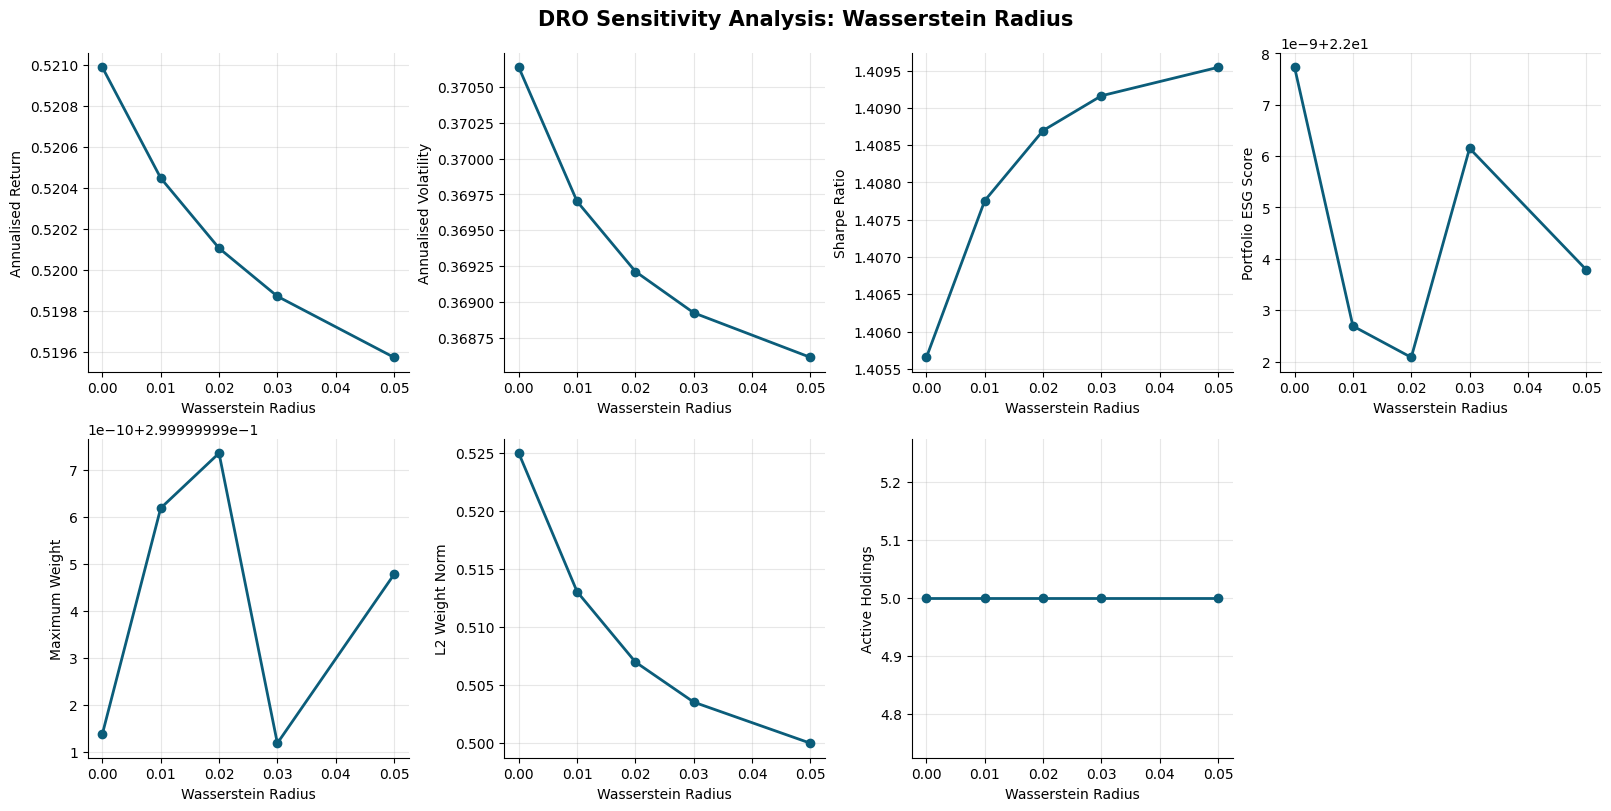

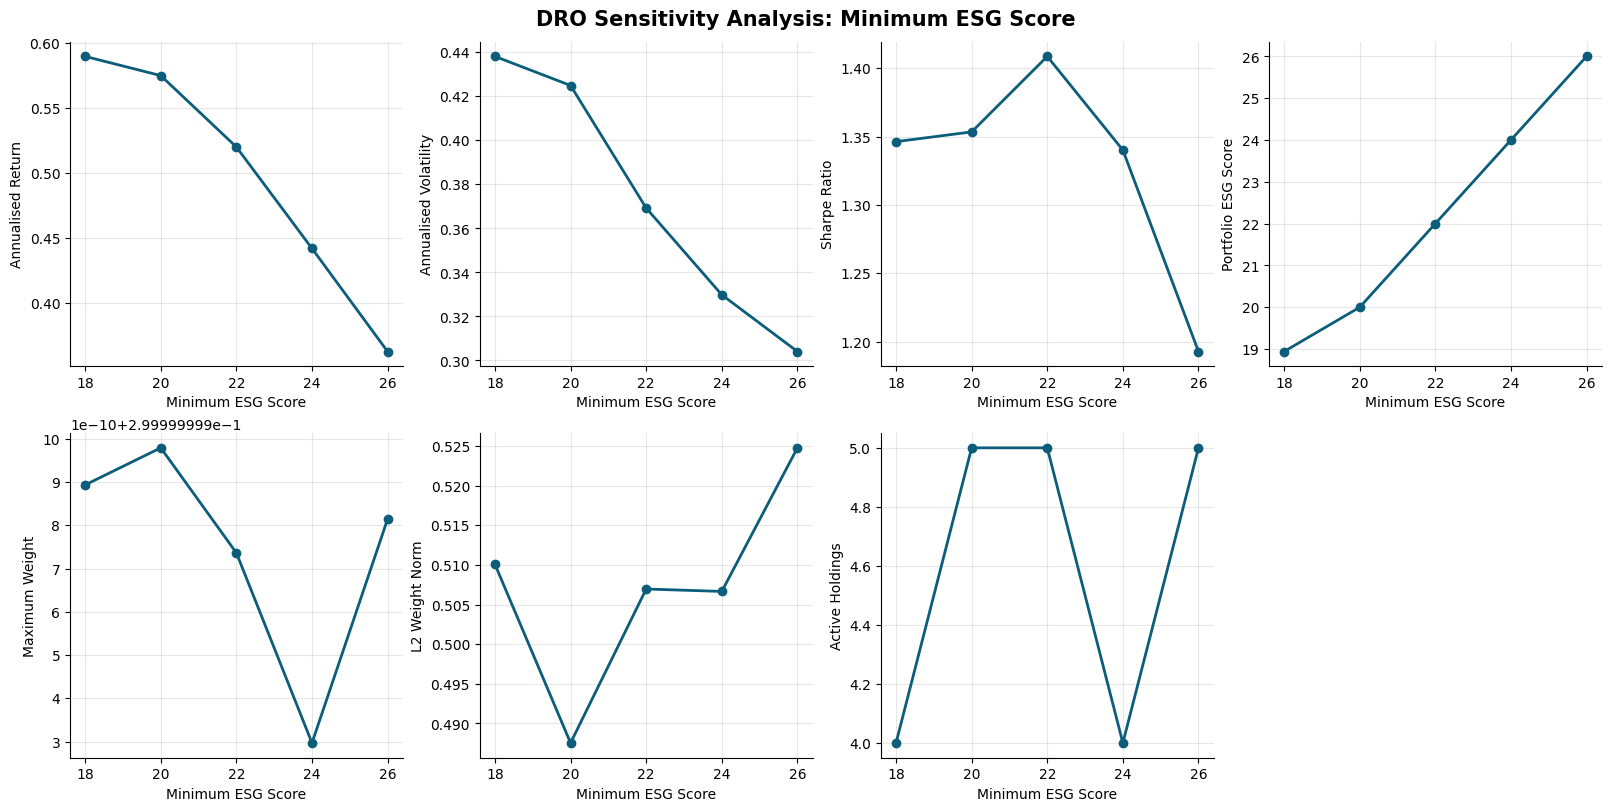

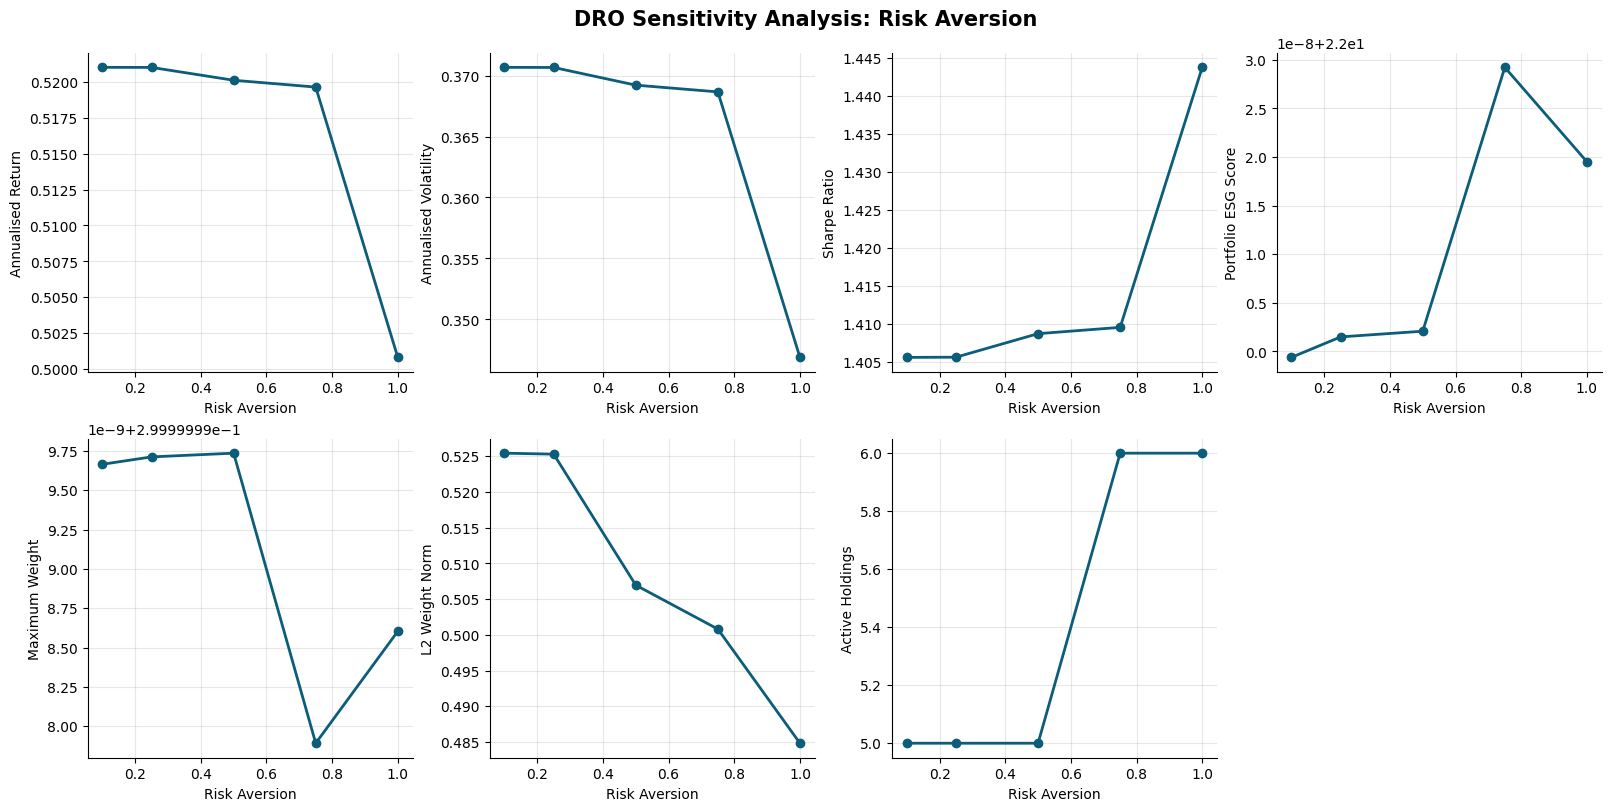

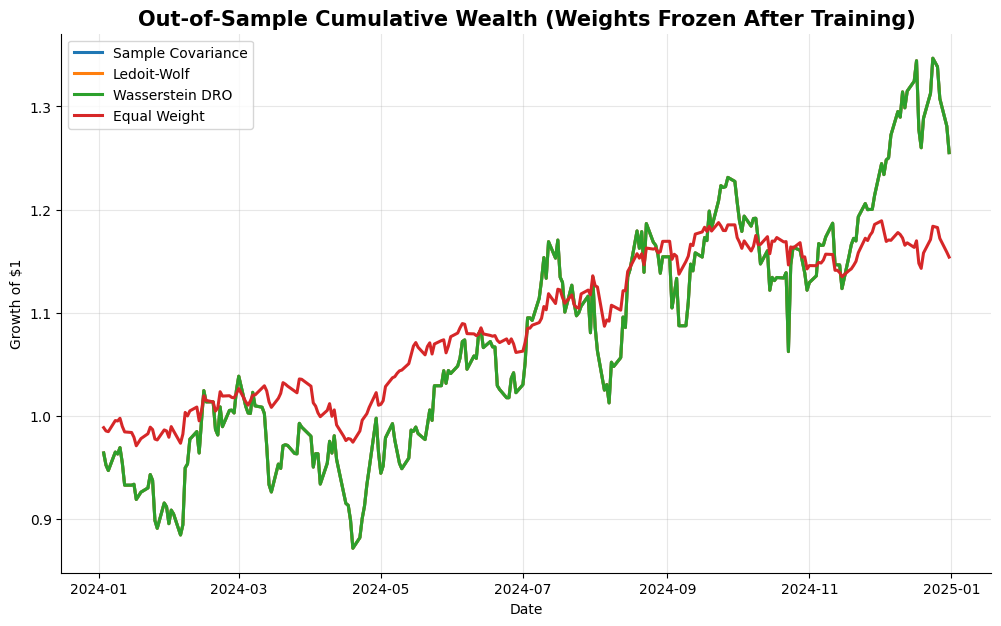

In [2]:
# EXTENSION OUTPUTS — run this after the self-contained extension cell above.

required_results = ['ext_epsilon_sensitivity', 'ext_esg_sensitivity',
                    'ext_lambda_sensitivity', 'ext_oos_table', 'ext_oos_wealth']
missing_results = [name for name in required_results if name not in globals()]
if missing_results:
    raise RuntimeError(
        'Run the SELF-CONTAINED EXTENSION cell immediately above first. Missing: ' +
        ', '.join(missing_results)
    )

percentage_columns = ['Annualised Return', 'Annualised Volatility',
                      'Maximum Weight', 'Cumulative Return', 'Maximum Drawdown']
format_rules = {column: '{:.2%}' for column in percentage_columns}
format_rules.update({'Sharpe Ratio': '{:.3f}', 'Portfolio ESG Score': '{:.2f}',
                     'L2 Weight Norm': '{:.4f}', 'Active Holdings': '{:.0f}'})

print('SENSITIVITY ANALYSIS — WASSERSTEIN RADIUS')
display(ext_epsilon_sensitivity.style.format(format_rules))

print('SENSITIVITY ANALYSIS — MINIMUM ESG SCORE')
display(ext_esg_sensitivity.style.format(format_rules))

print('SENSITIVITY ANALYSIS — RISK AVERSION')
display(ext_lambda_sensitivity.style.format(format_rules))

print('OUT-OF-SAMPLE PERFORMANCE — TEST PERIOD ONLY')
display(ext_oos_table.style.format(format_rules))

def ext_result_plot(table, x_column, title):
    metrics = ['Annualised Return', 'Annualised Volatility', 'Sharpe Ratio',
               'Portfolio ESG Score', 'Maximum Weight', 'L2 Weight Norm',
               'Active Holdings']
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
    for axis, metric in zip(axes.flat, metrics):
        axis.plot(table[x_column], table[metric], marker='o', linewidth=2, color='#0B5D7A')
        axis.set_xlabel(x_column)
        axis.set_ylabel(metric)
        axis.grid(alpha=0.3)
        axis.spines['top'].set_visible(False)
        axis.spines['right'].set_visible(False)
    axes.flat[-1].axis('off')
    fig.suptitle(title, fontsize=15, fontweight='bold')
    plt.show()

ext_result_plot(ext_epsilon_sensitivity, 'Wasserstein Radius',
                'DRO Sensitivity Analysis: Wasserstein Radius')
ext_result_plot(ext_esg_sensitivity, 'Minimum ESG Score',
                'DRO Sensitivity Analysis: Minimum ESG Score')
ext_result_plot(ext_lambda_sensitivity, 'Risk Aversion',
                'DRO Sensitivity Analysis: Risk Aversion')

fig, axis = plt.subplots(figsize=(12, 7))
for portfolio_name in ext_oos_wealth.columns:
    axis.plot(ext_oos_wealth.index, ext_oos_wealth[portfolio_name],
              linewidth=2.2, label=portfolio_name)
axis.set_title('Out-of-Sample Cumulative Wealth (Weights Frozen After Training)',
               fontsize=15, fontweight='bold')
axis.set_xlabel('Date')
axis.set_ylabel('Growth of $1')
axis.grid(alpha=0.3)
axis.legend()
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
plt.show()
